<a href="https://colab.research.google.com/github/udz2002/criteo-conversion-prediction/blob/main/notebooks/00_full_project_working.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# From Impressions to Conversions:
## Predictive Modelling for Display Advertising Performance

### MSc Data Science Project

This project investigates whether machine-learning models can predict whether a digital display advertising impression will be followed by a conversion.

The project uses the Criteo Attribution Modeling for Bidding Dataset, an anonymised dataset containing display advertising impressions from 30 days of live traffic.

The main research question is:

**To what extent can machine-learning models predict whether a digital display advertising impression will be followed by a conversion, and which modelling approach provides the best performance for this highly imbalanced classification problem?**

The project compares several classification approaches:

- Logistic Regression
- Decision Tree
- Random Forest
- Gradient Boosting using XGBoost
- Neural Network

Because conversions are rare, model performance will not be assessed using accuracy alone. Evaluation will include Precision, Recall, F1-score, ROC-AUC, PR-AUC, Log Loss and other relevant measures.

A chronological train-validation-test strategy is used to better represent the real-world scenario where historical advertising data are used to predict future conversions.

## 1. Project Aim and Objectives

### Aim

The aim of this project is to develop, optimise and compare machine-learning models for predicting conversion following a digital display advertising impression using the Criteo Attribution Modeling dataset.

### Objectives

The project has six objectives:

1. Explore the Criteo advertising dataset and identify patterns associated with conversions.
2. Develop an appropriate preprocessing pipeline for numerical, categorical and temporal advertising variables.
3. Investigate the effect of severe class imbalance on conversion prediction.
4. Develop and optimise several classification models.
5. Compare model performance using suitable evaluation metrics.
6. Assess how predictive modelling could support advertising optimisation while considering privacy, bias and responsible targeting.

The analysis will also consider the distinction between variables available at impression time and variables only known after an impression has occurred. This is important for preventing data leakage and ensuring that the predictive models represent a realistic advertising use case.

## 2. Environment Setup

The required Python libraries are installed and imported below.

The project uses:

- Pandas and NumPy for data handling
- Matplotlib for visualisation
- Scikit-learn for preprocessing, modelling and evaluation
- XGBoost for gradient boosted decision trees
- KaggleHub for accessing the dataset

A fixed random seed is used throughout the project to improve reproducibility.

In [13]:
!pip -q install kagglehub xgboost

In [14]:
import os
import gc
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Environment ready.")

Environment ready.


In [15]:
# Check package versions for reproducibility

import sklearn
import xgboost
import kagglehub

print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("Scikit-learn:", sklearn.__version__)
print("XGBoost:", xgboost.__version__)

Pandas: 2.2.3
NumPy: 2.1.3
Scikit-learn: 1.6.1
XGBoost: 3.4.1


## 3. Dataset Acquisition

The dataset used in this project is the **Criteo Attribution Modeling for Bidding Dataset**.

The original dataset was released by Criteo AI Lab to support research into attribution modelling, conversion modelling and real-time advertising bidding.

The dataset represents approximately 30 days of anonymised live advertising traffic.

Each row represents one display advertising impression. The available variables include information about the campaign, advertising context, clicks, conversions, cost and anonymised categorical characteristics.

The Kaggle-hosted version of the dataset is downloaded directly into Google Colab using KaggleHub.

In [16]:
import kagglehub

# Download the latest version of the dataset
path = kagglehub.dataset_download(
    "sharatsachin/criteo-attribution-modeling"
)

print("Dataset path:")
print(path)

Using Colab cache for faster access to the 'criteo-attribution-modeling' dataset.
Dataset path:
/kaggle/input/criteo-attribution-modeling


## 4. Dataset File Inspection

Before loading the full dataset, the files contained in the downloaded dataset are inspected.

This helps confirm the file format and ensures that the correct advertising dataset is loaded for analysis.

In [17]:
dataset_path = Path(path)

files = [f for f in dataset_path.rglob("*") if f.is_file()]

print("Files found:\n")

for f in files:
    size_mb = f.stat().st_size / (1024 ** 2)
    print(f"{f.name:<50} {size_mb:,.2f} MB")

Files found:

pcb_dataset_final.tsv                              2,469.91 MB


In [18]:
# Look for likely Criteo data files

data_candidates = [
    f for f in files
    if (
        ".tsv" in f.name.lower()
        or ".csv" in f.name.lower()
        or f.name.lower().endswith(".gz")
    )
]

print("Candidate data files:")

for i, f in enumerate(data_candidates):
    print(i, f)

Candidate data files:
0 /kaggle/input/criteo-attribution-modeling/pcb_dataset_final.tsv


In [19]:
# Select the largest candidate data file

data_file = max(
    data_candidates,
    key=lambda x: x.stat().st_size
)

print("Selected data file:")
print(data_file)

Selected data file:
/kaggle/input/criteo-attribution-modeling/pcb_dataset_final.tsv


## 5. Initial Dataset Inspection

A small number of rows are loaded before processing the complete dataset.

This allows the structure, column names and data types to be examined without using unnecessary memory.

In [20]:
# The Criteo attribution dataset is tab-separated

preview = pd.read_csv(
    data_file,
    sep="\t",
    compression="infer",
    nrows=10
)

preview

,timestamp,uid,campaign,conversion,conversion_timestamp,conversion_id,attribution,click,click_pos,click_nb,...,time_since_last_click,cat1,cat2,cat3,cat4,cat5,cat6,cat7,cat8,cat9
0,0,20073966,22589171,0,-1,-1,0,0,-1,-1,...,-1,5824233,9312274,3490278,29196072,11409686,1973606,25162884,29196072,29196072
1,2,24607497,884761,0,-1,-1,0,0,-1,-1,...,423858,30763035,9312274,14584482,29196072,11409686,1973606,22644417,9312274,21091111
2,2,28474333,18975823,0,-1,-1,0,0,-1,-1,...,8879,138937,9312274,10769841,29196072,5824237,138937,1795451,29196072,15351056
3,3,7306395,29427842,1,1449193,3063962,0,1,0,7,...,-1,28928366,26597095,12435261,23549932,5824237,1973606,9180723,29841067,29196072
4,3,25357769,13365547,0,-1,-1,0,0,-1,-1,...,-1,138937,26597094,31616034,29196072,11409684,26597096,4480345,29196072,29196072
5,4,93907,17686799,0,-1,-1,0,1,-1,-1,...,262565,30763035,9068207,9107790,29196072,32440044,1973606,2687461,29841067,21091108
6,4,19923387,31772643,0,-1,-1,0,0,-1,-1,...,179666,30763035,9312274,5028397,29196072,32440044,32440041,14074087,29196072,21091108
7,4,28451570,20843295,0,-1,-1,0,0,-1,-1,...,-1,138937,9312274,15403272,29196072,32440042,28928366,8556462,29196072,29196072
8,7,5588915,27491436,0,-1,-1,0,0,-1,-1,...,-1,138937,9312274,4281154,29196072,28928366,29196072,21857352,29196072,29196072
9,7,23074162,16184517,0,-1,-1,0,0,-1,-1,...,-1,28928366,26597095,7711526,29196072,3225250,1973606,17737135,9312274,29196072


In [21]:
print("Number of columns:", preview.shape[1])

print("\nColumn names:")
for col in preview.columns:
    print(col)

Number of columns: 22

Column names:
timestamp
uid
campaign
conversion
conversion_timestamp
conversion_id
attribution
click
click_pos
click_nb
cost
cpo
time_since_last_click
cat1
cat2
cat3
cat4
cat5
cat6
cat7
cat8
cat9


In [22]:
preview.dtypes

,0
timestamp,int64
uid,int64
campaign,int64
conversion,int64
conversion_timestamp,int64
conversion_id,int64
attribution,int64
click,int64
click_pos,int64
click_nb,int64


## 5.1 Dataset Variables

According to the original Criteo dataset documentation, the principal variables are:

- **timestamp** – time of the advertising impression.
- **uid** – anonymised unique user identifier.
- **campaign** – anonymised campaign identifier.
- **conversion** – whether a conversion occurred following the impression.
- **conversion_timestamp** – time at which the conversion occurred.
- **conversion_id** – anonymised identifier for the conversion.
- **attribution** – whether the conversion was attributed to Criteo.
- **click** – whether the advertising impression was clicked.
- **click_pos** – position of a click before conversion.
- **click_nb** – number of clicks associated with the conversion journey.
- **cost** – transformed advertising impression cost.
- **cpo** – transformed cost-per-order value for attributed conversions.
- **time_since_last_click** – elapsed time since the user's previous click.
- **cat1 to cat9** – anonymised categorical contextual advertising features.

The target variable for this project is **conversion**.

A value of 1 indicates that the impression was associated with a subsequent conversion, while 0 represents a non-converting impression.

## 6. Creation of a Representative Working Sample

The original dataset contains millions of advertising impressions and is too large to process efficiently using the computational resources available for this project.

The project therefore uses a reproducible sample of the original impressions.

Rather than loading the complete dataset into memory before sampling, the file is processed in chunks. The same sampling proportion is applied independently to every chunk.

This approach:

- reduces memory requirements;
- preserves observations throughout the 30-day period;
- avoids selecting only the beginning or end of the dataset;
- maintains approximately the original conversion prevalence;
- makes the experiment reproducible through a fixed random seed.

A 5% sample is initially used. The sampling percentage may later be increased if computational resources permit.

In [23]:
SAMPLE_FRAC = 0.05
CHUNK_SIZE = 250_000

sampled_chunks = []

total_rows = 0
total_conversions = 0

start_time = time.time()

for i, chunk in enumerate(
    pd.read_csv(
        data_file,
        sep="\t",
        compression="infer",
        chunksize=CHUNK_SIZE
    )
):

    total_rows += len(chunk)
    total_conversions += chunk["conversion"].sum()

    sampled_chunk = chunk.sample(
        frac=SAMPLE_FRAC,
        random_state=RANDOM_STATE + i
    )

    sampled_chunks.append(sampled_chunk)

    if (i + 1) % 10 == 0:
        print(
            f"Processed {total_rows:,} rows..."
        )

df = pd.concat(
    sampled_chunks,
    ignore_index=True
)

elapsed = time.time() - start_time

print("\nFinished.")
print(f"Original rows processed: {total_rows:,}")
print(f"Original conversions: {int(total_conversions):,}")
print(f"Sample rows: {len(df):,}")
print(f"Processing time: {elapsed / 60:.2f} minutes")

Processed 2,500,000 rows...
Processed 5,000,000 rows...
Processed 7,500,000 rows...
Processed 10,000,000 rows...
Processed 12,500,000 rows...
Processed 15,000,000 rows...

Finished.
Original rows processed: 16,468,027
Original conversions: 806,196
Sample rows: 823,401
Processing time: 0.90 minutes


In [24]:
original_conversion_rate = total_conversions / total_rows

sample_conversion_rate = df["conversion"].mean()

print(
    f"Original conversion rate: "
    f"{original_conversion_rate:.4%}"
)

print(
    f"Sample conversion rate: "
    f"{sample_conversion_rate:.4%}"
)

print(
    f"Difference: "
    f"{sample_conversion_rate - original_conversion_rate:.4%}"
)

Original conversion rate: 4.8955%
Sample conversion rate: 4.8936%
Difference: -0.0019%


### Sampling Assessment

The conversion prevalence of the sample is compared with the conversion prevalence observed while processing the complete dataset.

A similar conversion rate provides evidence that the working sample reasonably preserves the class distribution of the original dataset.

This is particularly important because conversion prediction is a highly imbalanced classification problem.

In [25]:
sample_file = "/content/criteo_5pct_sample.parquet"

df.to_parquet(
    sample_file,
    index=False
)

print("Sample saved to:")
print(sample_file)

Sample saved to:
/content/criteo_5pct_sample.parquet


## 7. Exploratory Data Analysis

Exploratory Data Analysis (EDA) is performed before modelling in order to understand the structure and quality of the advertising data.

The EDA examines:

- dataset dimensions;
- feature types;
- missing values;
- unusual placeholder values;
- class imbalance;
- click and conversion behaviour;
- campaign structure;
- temporal patterns;
- advertising cost;
- categorical feature cardinality.

The findings from this stage will be used to guide preprocessing and modelling decisions.

In [26]:
print("Dataset shape:")
print(df.shape)

print("\nRows:", f"{df.shape[0]:,}")
print("Columns:", df.shape[1])

Dataset shape:
(823401, 22)

Rows: 823,401
Columns: 22


In [27]:
df.head()

,timestamp,uid,campaign,conversion,conversion_timestamp,conversion_id,attribution,click,click_pos,click_nb,...,time_since_last_click,cat1,cat2,cat3,cat4,cat5,cat6,cat7,cat8,cat9
0,22855,15774610,21294794,0,-1,-1,0,1,-1,-1,...,1275548,138937,26597095,30608210,29196072,21611410,29196072,28797789,29196072,18291877
1,27009,5037589,28795042,0,-1,-1,0,0,-1,-1,...,610146,30763035,9312274,5477291,29196072,32440044,1973606,26305750,26597096,8661623
2,3008,26725493,27644431,0,-1,-1,0,0,-1,-1,...,-1,30763035,7477605,9002271,29196072,138937,3808271,9312274,29196072,29196072
3,33570,6554555,804100,0,-1,-1,0,0,-1,-1,...,741569,25259032,28928366,24877352,29196072,5824235,1973606,32081193,32440044,8661620
4,39355,6019390,15746419,0,-1,-1,0,0,-1,-1,...,-1,5824233,5642940,16436521,29196072,32440044,28928366,28630417,29196072,29196072


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 823401 entries, 0 to 823400
Data columns (total 22 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   timestamp              823401 non-null  int64  
 1   uid                    823401 non-null  int64  
 2   campaign               823401 non-null  int64  
 3   conversion             823401 non-null  int64  
 4   conversion_timestamp   823401 non-null  int64  
 5   conversion_id          823401 non-null  int64  
 6   attribution            823401 non-null  int64  
 7   click                  823401 non-null  int64  
 8   click_pos              823401 non-null  int64  
 9   click_nb               823401 non-null  int64  
 10  cost                   823401 non-null  float64
 11  cpo                    823401 non-null  float64
 12  time_since_last_click  823401 non-null  int64  
 13  cat1                   823401 non-null  int64  
 14  cat2                   823401 non-nu

## 7.1 Missing Data Assessment

Missing values can affect model training and may require removal, imputation or separate treatment.

The number and percentage of missing observations are therefore calculated for every variable.

In [29]:
missing = pd.DataFrame({
    "Missing_Count": df.isna().sum(),
    "Missing_Percentage": (
        df.isna().mean() * 100
    )
})

missing = missing.sort_values(
    "Missing_Count",
    ascending=False
)

missing

,Missing_Count,Missing_Percentage
timestamp,0,0.0
uid,0,0.0
campaign,0,0.0
conversion,0,0.0
conversion_timestamp,0,0.0
conversion_id,0,0.0
attribution,0,0.0
click,0,0.0
click_pos,0,0.0
click_nb,0,0.0


## 7.2 Placeholder and Sentinel Values

Some event-related variables use special values to represent the absence of an event.

For example, a missing conversion event may be represented using a value such as -1 rather than a conventional null value.

These values are inspected separately because they should not automatically be interpreted as genuine numerical measurements.

In [30]:
sentinel_summary = []

for col in df.columns:
    try:
        count_minus_one = (df[col] == -1).sum()

        if count_minus_one > 0:
            sentinel_summary.append({
                "Feature": col,
                "Minus_One_Count": count_minus_one,
                "Percentage": (
                    count_minus_one / len(df) * 100
                )
            })
    except:
        pass

sentinel_df = pd.DataFrame(sentinel_summary)

sentinel_df.sort_values(
    "Percentage",
    ascending=False
)

,Feature,Minus_One_Count,Percentage
0,conversion_timestamp,783107,95.106394
1,conversion_id,783107,95.106394
2,click_pos,783107,95.106394
3,click_nb,783107,95.106394
4,time_since_last_click,438686,53.277322


## 7.3 Duplicate Records

Exact duplicate observations are investigated to determine whether duplicate rows may influence the analysis.

Repeated impressions by the same user are not automatically duplicates because a user may legitimately receive multiple advertising impressions. Only completely identical rows are considered exact duplicates.

In [31]:
duplicate_count = df.duplicated().sum()

print(
    f"Exact duplicate rows: "
    f"{duplicate_count:,}"
)

print(
    f"Percentage of sample: "
    f"{duplicate_count / len(df):.4%}"
)

Exact duplicate rows: 0
Percentage of sample: 0.0000%


## 7.4 Conversion Class Distribution

The target variable is **conversion**.

Digital advertising conversion datasets commonly contain substantially more non-converting impressions than converting impressions.

This creates a class imbalance problem. Under severe imbalance, a model could achieve very high accuracy simply by predicting that almost every impression will not convert.

For this reason, accuracy will not be used as the primary measure of model quality.

In [32]:
conversion_counts = (
    df["conversion"]
    .value_counts()
    .sort_index()
)

conversion_percentages = (
    df["conversion"]
    .value_counts(normalize=True)
    .sort_index() * 100
)

conversion_summary = pd.DataFrame({
    "Count": conversion_counts,
    "Percentage": conversion_percentages
})

conversion_summary

,Count,Percentage
conversion,,
0,783107,95.106394
1,40294,4.893606


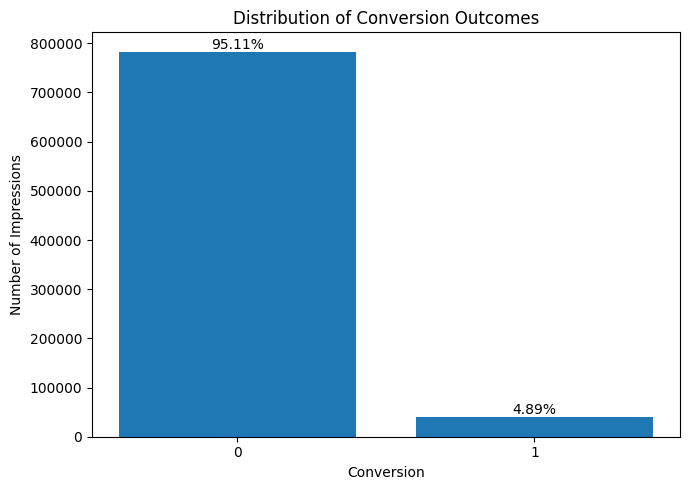

In [33]:
fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(
    conversion_summary.index.astype(str),
    conversion_summary["Count"]
)

ax.set_title(
    "Distribution of Conversion Outcomes"
)
ax.set_xlabel("Conversion")
ax.set_ylabel("Number of Impressions")

for bar, pct in zip(
    bars,
    conversion_summary["Percentage"]
):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{pct:.2f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

### Interpretation

The conversion distribution demonstrates whether the target variable is severely imbalanced.

The exact imbalance identified above will influence the selection of modelling techniques and performance metrics.

Because the positive conversion class is expected to represent only a small proportion of all advertising impressions, metrics such as Precision, Recall, F1-score and Precision-Recall AUC will be more informative than overall accuracy alone.

## 7.5 Click Behaviour

Click behaviour is explored because clicking an advertisement is closely related to advertising engagement.

However, a click occurs after the original advertising impression. Therefore, click information will not be included in the primary impression-time prediction model.

It will later be used in a separate diagnostic experiment to investigate how much predictive information becomes available after a click has occurred.

In [34]:
click_summary = pd.DataFrame({
    "Count": df["click"].value_counts().sort_index(),
    "Percentage": (
        df["click"]
        .value_counts(normalize=True)
        .sort_index() * 100
    )
})

click_summary

,Count,Percentage
click,,
0,526642,63.959359
1,296759,36.040641


In [35]:
click_conversion = pd.crosstab(
    df["click"],
    df["conversion"],
    normalize="index"
) * 100

click_conversion

conversion,0,1
click,,
0,100.000000,0.000000
1,86.421979,13.578021


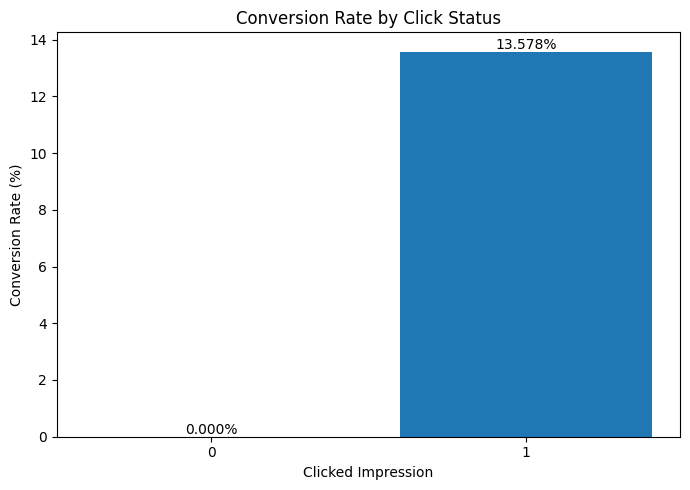

In [36]:
conversion_by_click = (
    df.groupby("click")["conversion"]
    .mean() * 100
)

fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(
    conversion_by_click.index.astype(str),
    conversion_by_click.values
)

ax.set_title(
    "Conversion Rate by Click Status"
)
ax.set_xlabel("Clicked Impression")
ax.set_ylabel("Conversion Rate (%)")

for bar, val in zip(
    bars,
    conversion_by_click.values
):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{val:.3f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

### Interpretation

The relationship between clicking and conversion provides useful evidence about the customer journey.

However, including click behaviour in a model intended to score an impression at the time it is displayed would introduce information that was not available when the impression originally occurred.

For this reason, click is treated as a post-impression variable and excluded from the primary model.

A separate click-informed experiment will later quantify how much predictive power is gained when post-impression engagement is available.

## 7.6 Campaign Structure

Advertising performance may vary substantially between campaigns because campaigns can have different products, audiences, creatives, targeting strategies and objectives.

The number of campaigns and the distribution of impressions across campaigns are therefore examined.

In [37]:
n_campaigns = df["campaign"].nunique()

print(
    f"Unique campaigns in working sample: "
    f"{n_campaigns:,}"
)

Unique campaigns in working sample: 675


In [38]:
campaign_summary = (
    df.groupby("campaign")
    .agg(
        Impressions=("conversion", "size"),
        Conversions=("conversion", "sum"),
        Conversion_Rate=("conversion", "mean")
    )
    .sort_values(
        "Impressions",
        ascending=False
    )
)

campaign_summary["Conversion_Rate"] *= 100

campaign_summary.head(20)

,Impressions,Conversions,Conversion_Rate
campaign,,,
10341182,21829,2273,10.412754
30801593,21395,1064,4.973125
17686799,19178,325,1.694650
15398570,18902,1210,6.401439
5061834,14788,519,3.509602
15184511,12947,1820,14.057311
29427842,11929,689,5.775840
28351001,11104,1138,10.248559
18975823,10836,554,5.112588


In [39]:
print(
    "Unique users:",
    f"{df['uid'].nunique():,}"
)

print(
    "Average impressions per user:",
    f"{len(df) / df['uid'].nunique():.2f}"
)

Unique users: 718,629
Average impressions per user: 1.15


### User Identifier Decision

Although the dataset contains an anonymised user identifier (`uid`), this variable will not be used directly as a predictor in the primary model.

A raw user ID is a high-cardinality identifier rather than an interpretable behavioural characteristic. Including it could encourage the model to memorise users that appear repeatedly rather than learn generalisable advertising patterns.

Excluding the raw user identifier also creates a more privacy-conscious and generalisable modelling approach.

## 7.7 Numerical Feature Summary

Descriptive statistics are calculated for numerical variables in order to identify their scale, range, central tendency and potential extreme values.

In [40]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
timestamp,823401.0,1.315412e+06,7.697757e+05,2.300000e+01,6.426960e+05,1.283493e+06,1.965983e+06,2.671199e+06
uid,823401.0,1.623800e+07,9.368860e+06,4.000000e+01,8.128094e+06,1.622603e+07,2.434509e+07,3.245875e+07
campaign,823401.0,1.698938e+07,9.696013e+06,7.332200e+04,8.892341e+06,1.556893e+07,2.685234e+07,3.245211e+07
conversion,823401.0,4.893606e-02,2.157345e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
conversion_timestamp,823401.0,9.511806e+04,4.792786e+05,-1.000000e+00,-1.000000e+00,-1.000000e+00,-1.000000e+00,5.262888e+06
conversion_id,823401.0,7.938902e+05,4.065225e+06,-1.000000e+00,-1.000000e+00,-1.000000e+00,-1.000000e+00,3.245852e+07
attribution,823401.0,2.673545e-02,1.613093e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
click,823401.0,3.604064e-01,4.801186e-01,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00
click_pos,823401.0,-8.303731e-01,1.567672e+00,-1.000000e+00,-1.000000e+00,-1.000000e+00,-1.000000e+00,1.710000e+02
click_nb,823401.0,-6.625702e-01,2.704305e+00,-1.000000e+00,-1.000000e+00,-1.000000e+00,-1.000000e+00,1.740000e+02


## 7.8 Categorical Feature Cardinality

The dataset includes several anonymised categorical contextual variables.

High-cardinality categorical variables require careful preprocessing because conventional one-hot encoding can produce a very large number of model features.

In [41]:
cat_columns = [
    c for c in df.columns
    if c.startswith("cat")
]

cardinality = pd.DataFrame({
    "Feature": ["campaign"] + cat_columns,
    "Unique_Values": [
        df[c].nunique()
        for c in ["campaign"] + cat_columns
    ]
})

cardinality.sort_values(
    "Unique_Values",
    ascending=False
)

,Feature,Unique_Values
7,cat7,21663
3,cat3,1785
0,campaign,675
2,cat2,64
5,cat5,51
9,cat9,30
6,cat6,30
4,cat4,18
8,cat8,11
1,cat1,9


## 7.9 Temporal Patterns

The dataset is chronologically ordered using an anonymised timestamp starting at zero.

The timestamp is converted into relative day and hour variables.

These variables do not represent actual calendar dates, but they allow temporal changes in impression volume and conversion behaviour to be investigated across the 30-day observation period.

In [42]:
SECONDS_PER_DAY = 60 * 60 * 24

df["day_index"] = (
    df["timestamp"] // SECONDS_PER_DAY
).astype(int)

df["hour_index"] = (
    (df["timestamp"] % SECONDS_PER_DAY) // 3600
).astype(int)

print(
    "Observed relative days:",
    df["day_index"].min(),
    "to",
    df["day_index"].max()
)

Observed relative days: 0 to 30


In [43]:
daily_summary = (
    df.groupby("day_index")
    .agg(
        Impressions=("conversion", "size"),
        Conversions=("conversion", "sum"),
        Conversion_Rate=("conversion", "mean")
    )
)

daily_summary["Conversion_Rate"] *= 100

daily_summary.head()

,Impressions,Conversions,Conversion_Rate
day_index,,,
0,28533,1386,4.857533
1,27887,1270,4.554093
2,26556,1282,4.827534
3,24872,1153,4.635735
4,29532,1439,4.872680


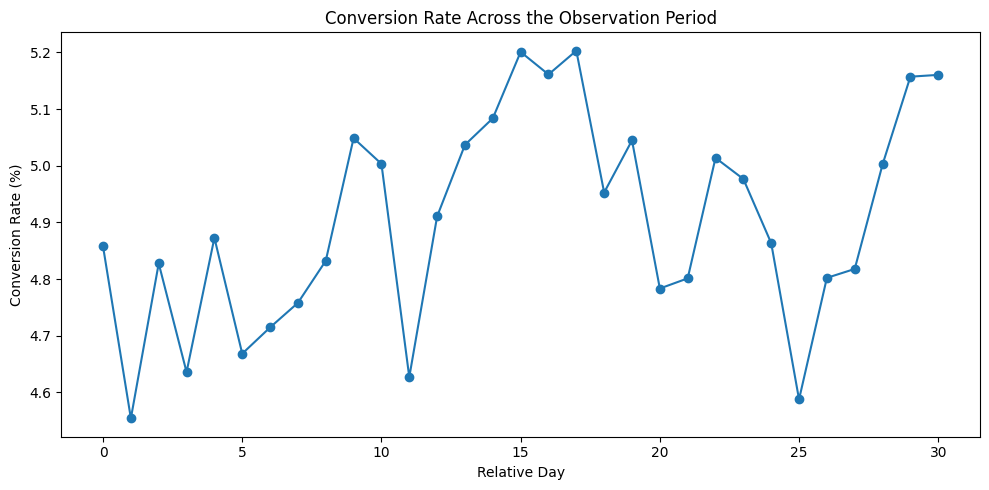

In [44]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    daily_summary.index,
    daily_summary["Conversion_Rate"],
    marker="o"
)

ax.set_title(
    "Conversion Rate Across the Observation Period"
)
ax.set_xlabel("Relative Day")
ax.set_ylabel("Conversion Rate (%)")

plt.tight_layout()
plt.show()

## 7.10 Advertising Cost

The dataset contains a transformed cost variable representing the cost associated with displaying an advertisement.

Although these values do not represent the original commercial prices, they can still be used to examine whether cost patterns differ between converting and non-converting impressions.

In [45]:
df.groupby("conversion")["cost"].describe()

,count,mean,std,min,25%,50%,75%,max
conversion,,,,,,,,
0,783107.0,0.000257,0.000738,0.00001,0.000021,0.000072,0.000216,0.051004
1,40294.0,0.000991,0.002151,0.00001,0.000120,0.000348,0.000948,0.046355


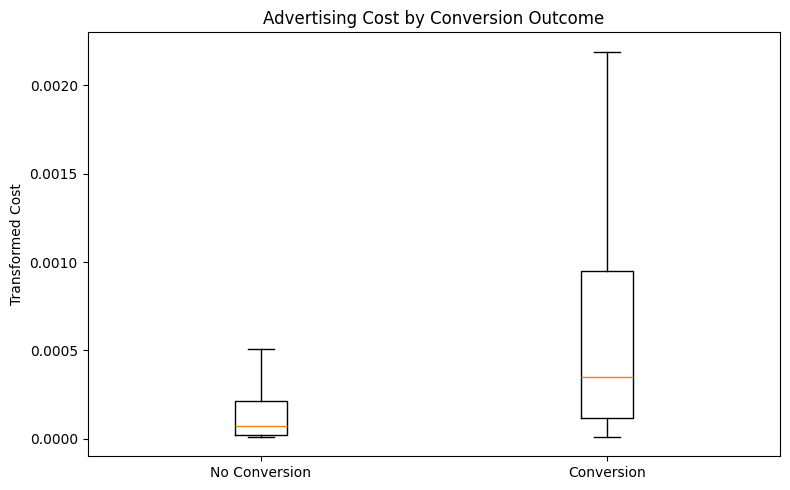

In [46]:
non_conversion_cost = (
    df.loc[df["conversion"] == 0, "cost"]
    .dropna()
)

conversion_cost = (
    df.loc[df["conversion"] == 1, "cost"]
    .dropna()
)

fig, ax = plt.subplots(figsize=(8, 5))

ax.boxplot(
    [non_conversion_cost, conversion_cost],
    labels=["No Conversion", "Conversion"],
    showfliers=False
)

ax.set_title(
    "Advertising Cost by Conversion Outcome"
)
ax.set_ylabel("Transformed Cost")

plt.tight_layout()
plt.show()

# 8. Feature Leakage Assessment

Before training a predictive model, each variable must be assessed according to when that information becomes available.

A variable constitutes data leakage when it contains information about the target that would not have been available at the time a prediction was intended to be made.

The objective of the primary model is to predict conversion from information available at or around the time an advertising impression is displayed.

The following variables are therefore excluded from the primary model:

| Variable | Reason for Exclusion |
|---|---|
| conversion_timestamp | Only exists if/when the future conversion occurs |
| conversion_id | Directly identifies a future conversion event |
| attribution | Depends on the conversion/attribution outcome |
| cpo | Cost-per-order is dependent on an attributed conversion |
| click | Occurs after the impression |
| click_pos | Requires subsequent click/conversion journey information |
| click_nb | Requires subsequent journey information |
| uid | High-cardinality user identifier with risk of memorisation |

The `conversion` variable is retained only as the prediction target.

The primary model therefore focuses on campaign, cost, historical interaction timing, relative time and anonymised contextual features.

A later ablation experiment will introduce the `click` variable separately to measure how much predictive information becomes available after engagement with the advertisement.

# 9. Feature Engineering

Several additional variables are constructed from information available in the dataset.

The raw timestamp is converted into relative day and hour variables.

The `time_since_last_click` variable can contain values representing the absence of a previous click. Two derived variables are therefore created:

- whether a previous click exists;
- the log-transformed elapsed time since the previous click.

The logarithmic transformation reduces the effect of extremely large elapsed-time values while preserving their relative ordering.

In [47]:
df["has_previous_click"] = (
    df["time_since_last_click"] >= 0
).astype("int8")

df["time_since_last_click_clean"] = (
    df["time_since_last_click"]
    .clip(lower=0)
)

df["log_time_since_last_click"] = np.log1p(
    df["time_since_last_click_clean"]
)

df[
    [
        "time_since_last_click",
        "has_previous_click",
        "log_time_since_last_click"
    ]
].describe()

,time_since_last_click,has_previous_click,log_time_since_last_click
count,8.234010e+05,823401.000000,823401.000000
mean,2.714354e+05,0.467227,5.552133
std,5.279103e+05,0.498925,6.216878
min,-1.000000e+00,0.000000,0.000000
25%,-1.000000e+00,0.000000,0.000000
50%,-1.000000e+00,0.000000,0.000000
75%,2.727100e+05,1.000000,12.516168
max,2.591996e+06,1.000000,14.767939


In [48]:
TARGET = "conversion"

categorical_features = [
    "campaign",
    "cat1",
    "cat2",
    "cat3",
    "cat4",
    "cat5",
    "cat6",
    "cat7",
    "cat8",
    "cat9"
]

numeric_features = [
    "cost",
    "day_index",
    "hour_index",
    "has_previous_click",
    "log_time_since_last_click"
]

model_features = (
    categorical_features +
    numeric_features
)

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numeric_features)

print("\nTotal model features:")
print(len(model_features))

Categorical features:
['campaign', 'cat1', 'cat2', 'cat3', 'cat4', 'cat5', 'cat6', 'cat7', 'cat8', 'cat9']

Numerical features:
['cost', 'day_index', 'hour_index', 'has_previous_click', 'log_time_since_last_click']

Total model features:
15


# 10. Training, Validation and Test Strategy

A chronological data split is used instead of a purely random split.

This decision reflects the real-world advertising scenario where historical observations are used to predict future behaviour.

After sorting impressions by timestamp:

- the earliest 70% of observations are used for training;
- the next 15% are used for validation;
- the final 15% are retained as an unseen test set.

The validation dataset is used for model selection, hyperparameter optimisation and classification-threshold selection.

The test dataset is not used during model development and is reserved for final model evaluation.

This design also reduces the risk that information from future advertising traffic influences model training.

In [49]:
df_model = (
    df.sort_values("timestamp")
    .reset_index(drop=True)
)

n = len(df_model)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_df = df_model.iloc[:train_end].copy()
val_df = df_model.iloc[train_end:val_end].copy()
test_df = df_model.iloc[val_end:].copy()

print("Training rows:", f"{len(train_df):,}")
print("Validation rows:", f"{len(val_df):,}")
print("Test rows:", f"{len(test_df):,}")

Training rows: 576,380
Validation rows: 123,510
Test rows: 123,511


In [50]:
split_summary = pd.DataFrame({
    "Dataset": [
        "Training",
        "Validation",
        "Test"
    ],
    "Rows": [
        len(train_df),
        len(val_df),
        len(test_df)
    ],
    "Conversions": [
        train_df[TARGET].sum(),
        val_df[TARGET].sum(),
        test_df[TARGET].sum()
    ],
    "Conversion_Rate": [
        train_df[TARGET].mean(),
        val_df[TARGET].mean(),
        test_df[TARGET].mean()
    ]
})

split_summary["Conversion_Rate"] *= 100

split_summary

,Dataset,Rows,Conversions,Conversion_Rate
0,Training,576380,28183,4.889656
1,Validation,123510,5980,4.841713
2,Test,123511,6131,4.963930


In [51]:
X_train = train_df[model_features].copy()
y_train = train_df[TARGET].astype(int)

X_val = val_df[model_features].copy()
y_val = val_df[TARGET].astype(int)

X_test = test_df[model_features].copy()
y_test = test_df[TARGET].astype(int)

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(576380, 15)
(123510, 15)
(123511, 15)


# 11. Data Preprocessing

Different preprocessing techniques are applied to numerical and categorical variables.

### Numerical variables

Numerical variables are:

1. imputed using the median where necessary;
2. standardised using StandardScaler.

### Categorical variables

Categorical variables are:

1. imputed using their most frequent value where necessary;
2. converted using one-hot encoding.

Because some advertising variables have high cardinality, the encoder limits the number of retained categories. Infrequent categories are grouped together.

The preprocessing pipeline is fitted using the training data only. This prevents information from the validation or test periods from influencing model preparation.

In [52]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)
from sklearn.impute import SimpleImputer

In [53]:
numeric_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler(with_mean=False)
    )
])

categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "onehot",
        OneHotEncoder(
            handle_unknown="infrequent_if_exist",
            max_categories=100,
            sparse_output=True
        )
    )
])

preprocessor = ColumnTransformer([
    (
        "numeric",
        numeric_pipeline,
        numeric_features
    ),
    (
        "categorical",
        categorical_pipeline,
        categorical_features
    )
])

In [54]:
print("Fitting preprocessing pipeline...")

X_train_processed = preprocessor.fit_transform(
    X_train
)

X_val_processed = preprocessor.transform(
    X_val
)

X_test_processed = preprocessor.transform(
    X_test
)

print(
    "Training matrix:",
    X_train_processed.shape
)

print(
    "Validation matrix:",
    X_val_processed.shape
)

print(
    "Test matrix:",
    X_test_processed.shape
)

Fitting preprocessing pipeline...
Training matrix: (576380, 517)
Validation matrix: (123510, 517)
Test matrix: (123511, 517)


In [55]:
feature_names = (
    preprocessor
    .get_feature_names_out()
)

print(
    "Total processed features:",
    len(feature_names)
)

print("\nExample features:")
print(feature_names[:30])

Total processed features: 517

Example features:
['numeric__cost' 'numeric__day_index' 'numeric__hour_index'
 'numeric__has_previous_click' 'numeric__log_time_since_last_click'
 'categorical__campaign_83677' 'categorical__campaign_497593'
 'categorical__campaign_716288' 'categorical__campaign_2390251'
 'categorical__campaign_2576437' 'categorical__campaign_2828357'
 'categorical__campaign_2865314' 'categorical__campaign_2869134'
 'categorical__campaign_2946551' 'categorical__campaign_3892353'
 'categorical__campaign_4293600' 'categorical__campaign_4814007'
 'categorical__campaign_4869922' 'categorical__campaign_5044698'
 'categorical__campaign_5061834' 'categorical__campaign_5544859'
 'categorical__campaign_5686703' 'categorical__campaign_5867090'
 'categorical__campaign_6686701' 'categorical__campaign_6686704'
 'categorical__campaign_6810200' 'categorical__campaign_6886817'
 'categorical__campaign_7061828' 'categorical__campaign_7121544'
 'categorical__campaign_7289590']


# 12. Model Evaluation Strategy

Because conversion is a rare event, model performance is assessed using several complementary measures.

### Precision

Precision measures the proportion of impressions predicted to convert that actually converted.

High precision is valuable when an advertiser wants to avoid spending budget on impressions unlikely to produce a conversion.

### Recall

Recall measures the proportion of actual conversions successfully identified by the model.

High recall is important when missing a potential converter has a significant opportunity cost.

### F1-score

F1-score represents the harmonic mean of Precision and Recall and provides a balanced measure when both are important.

### ROC-AUC

ROC-AUC measures the model's ability to rank converting impressions above non-converting impressions across different thresholds.

### PR-AUC / Average Precision

Precision-Recall performance is particularly important for highly imbalanced datasets because it focuses directly on the model's ability to identify the rare positive class.

Average Precision is used in this project as the summary measure of Precision-Recall performance.

### Log Loss

Log Loss evaluates the quality of predicted probabilities and penalises confident incorrect predictions.

### Brier Score

The Brier Score measures the squared difference between predicted conversion probabilities and actual outcomes and provides additional information about probability calibration.

Accuracy is calculated only as a supporting measure and is not used as the main criterion for selecting the best model.

In [56]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    log_loss,
    brier_score_loss,
    confusion_matrix,
    precision_recall_curve,
    roc_curve
)

In [57]:
def evaluate_probabilities(
    y_true,
    probabilities,
    threshold=0.5
):

    probabilities = np.clip(
        probabilities,
        1e-7,
        1 - 1e-7
    )

    predictions = (
        probabilities >= threshold
    ).astype(int)

    results = {
        "Accuracy": accuracy_score(
            y_true,
            predictions
        ),
        "Precision": precision_score(
            y_true,
            predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            y_true,
            predictions,
            zero_division=0
        ),
        "F1": f1_score(
            y_true,
            predictions,
            zero_division=0
        ),
        "ROC_AUC": roc_auc_score(
            y_true,
            probabilities
        ),
        "PR_AUC": average_precision_score(
            y_true,
            probabilities
        ),
        "Log_Loss": log_loss(
            y_true,
            probabilities
        ),
        "Brier_Score": brier_score_loss(
            y_true,
            probabilities
        )
    }

    return results

## 12.1 Classification Threshold Optimisation

The conventional probability threshold of 0.5 is not necessarily appropriate for a highly imbalanced conversion dataset.

A threshold is therefore selected using the validation dataset.

The threshold that produces the highest F1-score on the validation data is identified.

The test dataset remains untouched during threshold selection.

In [58]:
def find_best_f1_threshold(
    y_true,
    probabilities
):

    precision, recall, thresholds = (
        precision_recall_curve(
            y_true,
            probabilities
        )
    )

    f1_scores = (
        2 * precision * recall /
        (precision + recall + 1e-12)
    )

    # Last precision/recall pair has no threshold
    best_index = np.argmax(
        f1_scores[:-1]
    )

    best_threshold = thresholds[
        best_index
    ]

    best_f1 = f1_scores[
        best_index
    ]

    return best_threshold, best_f1

# 13. Baseline Model

Before evaluating sophisticated machine-learning algorithms, a naive baseline model is created.

The baseline predicts conversion probabilities based only on the overall prevalence of the conversion class.

A useful predictive model should outperform this baseline, particularly in Precision-Recall performance.

In [59]:
from sklearn.dummy import DummyClassifier

dummy_model = DummyClassifier(
    strategy="prior"
)

dummy_model.fit(
    X_train_processed,
    y_train
)

dummy_val_prob = (
    dummy_model.predict_proba(
        X_val_processed
    )[:, 1]
)

dummy_results = evaluate_probabilities(
    y_val,
    dummy_val_prob
)

pd.DataFrame(
    [dummy_results],
    index=["Dummy Baseline"]
)

,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,Log_Loss,Brier_Score
Dummy Baseline,0.951583,0.0,0.0,0.0,0.5,0.048417,0.19383,0.046073


## 13.1 Hyperparameter Optimisation Strategy

The complete training dataset is relatively large.

To make model optimisation computationally practical, hyperparameter trials are initially performed using a representative stratified subset of the training data.

The best configuration is selected using performance on the separate validation dataset.

After model selection, the chosen configuration is retrained using the complete training set.

This approach allows several model configurations to be investigated without using the test dataset during optimisation.

In [60]:
from sklearn.model_selection import train_test_split

TUNE_SAMPLE_SIZE = min(
    200_000,
    len(y_train)
)

if len(y_train) > TUNE_SAMPLE_SIZE:

    tune_indices, _ = train_test_split(
        np.arange(len(y_train)),
        train_size=TUNE_SAMPLE_SIZE,
        stratify=y_train,
        random_state=RANDOM_STATE
    )

else:
    tune_indices = np.arange(
        len(y_train)
    )

X_tune = X_train_processed[
    tune_indices
]

y_tune = y_train.iloc[
    tune_indices
]

print(
    "Tuning observations:",
    f"{len(y_tune):,}"
)

print(
    "Tuning conversions:",
    f"{y_tune.sum():,}"
)

print(
    "Conversion rate:",
    f"{y_tune.mean():.4%}"
)

Tuning observations: 200,000
Tuning conversions: 9,779
Conversion rate: 4.8895%


# 14. Logistic Regression

Logistic Regression provides a strong and interpretable baseline for binary classification.

It estimates the probability of conversion using a logistic function applied to a weighted combination of the input variables.

The model is particularly useful as a benchmark because its behaviour can be compared with more flexible non-linear models.

Several values of the regularisation parameter `C` and different approaches to class weighting are tested.

In [61]:
from sklearn.linear_model import LogisticRegression

logistic_configs = [
    {
        "C": 0.1,
        "class_weight": None
    },
    {
        "C": 1.0,
        "class_weight": None
    },
    {
        "C": 0.1,
        "class_weight": "balanced"
    },
    {
        "C": 1.0,
        "class_weight": "balanced"
    }
]

logistic_trials = []

for config in logistic_configs:

    print("Testing:", config)

    model = LogisticRegression(
        C=config["C"],
        class_weight=config[
            "class_weight"
        ],
        solver="saga",
        max_iter=300,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    model.fit(
        X_tune,
        y_tune
    )

    val_prob = model.predict_proba(
        X_val_processed
    )[:, 1]

    metrics = evaluate_probabilities(
        y_val,
        val_prob
    )

    logistic_trials.append({
        **config,
        **metrics
    })

logistic_trials_df = pd.DataFrame(
    logistic_trials
)

logistic_trials_df.sort_values(
    "PR_AUC",
    ascending=False
)

Testing: {'C': 0.1, 'class_weight': None}
Testing: {'C': 1.0, 'class_weight': None}
Testing: {'C': 0.1, 'class_weight': 'balanced'}
Testing: {'C': 1.0, 'class_weight': 'balanced'}


,C,class_weight,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,Log_Loss,Brier_Score
0,0.1,None,0.952020,0.541925,0.058361,0.105374,0.832346,0.270836,0.154196,0.040093
1,1.0,None,0.952085,0.546407,0.061037,0.109807,0.831878,0.270160,0.154235,0.040102
2,0.1,balanced,0.791685,0.153368,0.730602,0.253518,0.836613,0.258153,0.493836,0.155708
3,1.0,balanced,0.789944,0.152268,0.730936,0.252033,0.835624,0.257211,0.494279,0.156216


### Logistic Regression Optimisation

The logistic regression experiments compare regularisation strength and class weighting.

Class weighting is particularly relevant because the conversion class is substantially smaller than the non-conversion class.

The configuration with the strongest validation PR-AUC will be selected for final training.

In [62]:
from sklearn.tree import DecisionTreeClassifier

tree_configs = [
    {
        "max_depth": 5,
        "min_samples_leaf": 100
    },
    {
        "max_depth": 8,
        "min_samples_leaf": 100
    },
    {
        "max_depth": 12,
        "min_samples_leaf": 100
    },
    {
        "max_depth": 12,
        "min_samples_leaf": 50
    }
]

tree_trials = []

for config in tree_configs:

    print("Testing:", config)

    model = DecisionTreeClassifier(
        max_depth=config[
            "max_depth"
        ],
        min_samples_leaf=config[
            "min_samples_leaf"
        ],
        class_weight="balanced",
        random_state=RANDOM_STATE
    )

    model.fit(
        X_tune,
        y_tune
    )

    val_prob = model.predict_proba(
        X_val_processed
    )[:, 1]

    metrics = evaluate_probabilities(
        y_val,
        val_prob
    )

    tree_trials.append({
        **config,
        **metrics
    })

tree_trials_df = pd.DataFrame(
    tree_trials
)

tree_trials_df.sort_values(
    "PR_AUC",
    ascending=False
)

Testing: {'max_depth': 5, 'min_samples_leaf': 100}
Testing: {'max_depth': 8, 'min_samples_leaf': 100}
Testing: {'max_depth': 12, 'min_samples_leaf': 100}
Testing: {'max_depth': 12, 'min_samples_leaf': 50}


,max_depth,min_samples_leaf,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,Log_Loss,Brier_Score
1,8,100,0.792802,0.150066,0.703177,0.247346,0.830015,0.262829,0.491199,0.159265
3,12,50,0.785386,0.145707,0.705853,0.241552,0.815054,0.260366,0.497699,0.156908
2,12,100,0.806251,0.153956,0.667726,0.250219,0.819142,0.258797,0.487173,0.155859
0,5,100,0.771282,0.141713,0.736455,0.237688,0.821425,0.242021,0.512293,0.167443


# 16. Random Forest

Random Forest combines predictions from multiple decision trees.

The use of many trees can reduce the instability and overfitting associated with a single Decision Tree.

The model is tested using different numbers of trees and maximum tree depths.

Balanced class weighting is used to reduce the dominance of the non-conversion class.

In [63]:
from sklearn.ensemble import RandomForestClassifier

forest_configs = [
    {
        "n_estimators": 100,
        "max_depth": 12
    },
    {
        "n_estimators": 200,
        "max_depth": 12
    },
    {
        "n_estimators": 100,
        "max_depth": 20
    },
    {
        "n_estimators": 200,
        "max_depth": 20
    }
]

forest_trials = []

for config in forest_configs:

    print("Testing:", config)

    model = RandomForestClassifier(
        n_estimators=config[
            "n_estimators"
        ],
        max_depth=config[
            "max_depth"
        ],
        min_samples_leaf=20,
        class_weight="balanced_subsample",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    model.fit(
        X_tune,
        y_tune
    )

    val_prob = model.predict_proba(
        X_val_processed
    )[:, 1]

    metrics = evaluate_probabilities(
        y_val,
        val_prob
    )

    forest_trials.append({
        **config,
        **metrics
    })

forest_trials_df = pd.DataFrame(
    forest_trials
)

forest_trials_df.sort_values(
    "PR_AUC",
    ascending=False
)

Testing: {'n_estimators': 100, 'max_depth': 12}
Testing: {'n_estimators': 200, 'max_depth': 12}
Testing: {'n_estimators': 100, 'max_depth': 20}
Testing: {'n_estimators': 200, 'max_depth': 20}


,n_estimators,max_depth,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,Log_Loss,Brier_Score
3,200,20,0.802656,0.158333,0.712709,0.259104,0.844930,0.283183,0.479460,0.152589
2,100,20,0.802340,0.157774,0.710535,0.258212,0.844245,0.281871,0.480105,0.152875
0,100,12,0.798000,0.153509,0.702676,0.251971,0.833857,0.271509,0.514904,0.166026
1,200,12,0.794073,0.152060,0.710870,0.250530,0.836250,0.270822,0.514563,0.165940


# 17. Gradient Boosting with XGBoost

Gradient boosting builds decision trees sequentially, with each new tree focusing on errors made by the existing ensemble.

XGBoost is widely used for structured and tabular classification problems because it can model complex non-linear relationships and feature interactions.

The learning rate, tree depth, number of trees and imbalance weighting are explored.

The `scale_pos_weight` parameter allows greater importance to be assigned to rare conversion observations.

In [64]:
from xgboost import XGBClassifier

positive_count = y_tune.sum()
negative_count = len(y_tune) - positive_count

imbalance_ratio = (
    negative_count / positive_count
)

print(
    "Negative-to-positive ratio:",
    f"{imbalance_ratio:.2f}"
)

Negative-to-positive ratio: 19.45


In [65]:
xgb_configs = [
    {
        "n_estimators": 200,
        "max_depth": 3,
        "learning_rate": 0.10,
        "scale_pos_weight": 1
    },
    {
        "n_estimators": 300,
        "max_depth": 3,
        "learning_rate": 0.05,
        "scale_pos_weight": imbalance_ratio
    },
    {
        "n_estimators": 300,
        "max_depth": 6,
        "learning_rate": 0.05,
        "scale_pos_weight": imbalance_ratio
    },
    {
        "n_estimators": 300,
        "max_depth": 6,
        "learning_rate": 0.10,
        "scale_pos_weight": np.sqrt(
            imbalance_ratio
        )
    }
]

xgb_trials = []

for config in xgb_configs:

    print("Testing:")
    print(config)

    model = XGBClassifier(
        **config,
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    model.fit(
        X_tune,
        y_tune
    )

    val_prob = model.predict_proba(
        X_val_processed
    )[:, 1]

    metrics = evaluate_probabilities(
        y_val,
        val_prob
    )

    xgb_trials.append({
        **config,
        **metrics
    })

xgb_trials_df = pd.DataFrame(
    xgb_trials
)

xgb_trials_df.sort_values(
    "PR_AUC",
    ascending=False
)

Testing:
{'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.1, 'scale_pos_weight': 1}
Testing:
{'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.05, 'scale_pos_weight': np.float64(19.451988955925962)}
Testing:
{'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.05, 'scale_pos_weight': np.float64(19.451988955925962)}
Testing:
{'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.1, 'scale_pos_weight': np.float64(4.410440902667891)}


,n_estimators,max_depth,learning_rate,scale_pos_weight,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,Log_Loss,Brier_Score
0,200,3,0.10,1.000000,0.952733,0.591495,0.076756,0.135879,0.853366,0.307384,0.147739,0.038910
2,300,6,0.05,19.451989,0.808186,0.164552,0.726421,0.268322,0.852297,0.304917,0.437724,0.140258
3,300,6,0.10,4.410441,0.934572,0.343513,0.385619,0.363350,0.852073,0.303441,0.198401,0.053553
1,300,3,0.05,19.451989,0.789215,0.154765,0.751672,0.256681,0.852104,0.303279,0.470861,0.152652


# 18. Neural Network

A Multi-Layer Perceptron (MLP) neural network is included to compare traditional statistical and tree-based methods with a neural learning approach.

Neural networks can represent complex non-linear interactions but may require larger computational resources and careful optimisation.

Because the conversion class is extremely rare, a training subset containing all available positive observations and a controlled sample of negative observations is used for the neural network.

The untouched validation and test datasets retain their original class distributions.

In [66]:
from sklearn.neural_network import MLPClassifier

In [67]:
# Create a manageable training dataset for the MLP

y_train_array = y_train.to_numpy()

positive_indices = np.where(
    y_train_array == 1
)[0]

negative_indices = np.where(
    y_train_array == 0
)[0]

NEGATIVE_TO_POSITIVE_RATIO = 50

n_negative_required = min(
    len(negative_indices),
    len(positive_indices)
    * NEGATIVE_TO_POSITIVE_RATIO
)

rng = np.random.default_rng(
    RANDOM_STATE
)

selected_negative_indices = rng.choice(
    negative_indices,
    size=n_negative_required,
    replace=False
)

mlp_indices = np.concatenate([
    positive_indices,
    selected_negative_indices
])

rng.shuffle(mlp_indices)

X_mlp_train = X_train_processed[
    mlp_indices
]

y_mlp_train = y_train_array[
    mlp_indices
]

print(
    "MLP training rows:",
    f"{len(y_mlp_train):,}"
)

print(
    "MLP positive observations:",
    f"{y_mlp_train.sum():,}"
)

print(
    "MLP training conversion rate:",
    f"{y_mlp_train.mean():.4%}"
)

MLP training rows: 576,380
MLP positive observations: 28,183
MLP training conversion rate: 4.8897%


In [68]:
mlp_configs = [
    {
        "hidden_layer_sizes": (64, 32),
        "alpha": 0.0001
    },
    {
        "hidden_layer_sizes": (128, 64, 32),
        "alpha": 0.0001
    },
    {
        "hidden_layer_sizes": (64, 32),
        "alpha": 0.001
    }
]

mlp_trials = []

for config in mlp_configs:

    print("Testing:", config)

    model = MLPClassifier(
        hidden_layer_sizes=config[
            "hidden_layer_sizes"
        ],
        alpha=config["alpha"],
        learning_rate_init=0.001,
        batch_size=1024,
        max_iter=30,
        early_stopping=True,
        validation_fraction=0.1,
        random_state=RANDOM_STATE
    )

    model.fit(
        X_mlp_train,
        y_mlp_train
    )

    val_prob = model.predict_proba(
        X_val_processed
    )[:, 1]

    metrics = evaluate_probabilities(
        y_val,
        val_prob
    )

    mlp_trials.append({
        **config,
        **metrics
    })

mlp_trials_df = pd.DataFrame(
    mlp_trials
)

mlp_trials_df.sort_values(
    "PR_AUC",
    ascending=False
)

Testing: {'hidden_layer_sizes': (64, 32), 'alpha': 0.0001}
Testing: {'hidden_layer_sizes': (128, 64, 32), 'alpha': 0.0001}
Testing: {'hidden_layer_sizes': (64, 32), 'alpha': 0.001}


,hidden_layer_sizes,alpha,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,Log_Loss,Brier_Score
2,"(64, 32)",0.0010,0.952830,0.610951,0.070903,0.127060,0.850770,0.303461,0.150375,0.039188
0,"(64, 32)",0.0001,0.952878,0.610497,0.073913,0.131862,0.850161,0.303382,0.150927,0.039211
1,"(128, 64, 32)",0.0001,0.952822,0.597701,0.078261,0.138400,0.847277,0.301037,0.149847,0.039185


# 19. Model Optimisation Results

The best-performing configuration for each modelling approach is identified using validation PR-AUC.

PR-AUC is used as the primary optimisation measure because the conversion class is rare and the project's principal objective is to distinguish potential converters from a much larger group of non-converters.

In [69]:
best_logistic = (
    logistic_trials_df
    .sort_values(
        "PR_AUC",
        ascending=False
    )
    .iloc[0]
)

best_tree = (
    tree_trials_df
    .sort_values(
        "PR_AUC",
        ascending=False
    )
    .iloc[0]
)

best_forest = (
    forest_trials_df
    .sort_values(
        "PR_AUC",
        ascending=False
    )
    .iloc[0]
)

best_xgb = (
    xgb_trials_df
    .sort_values(
        "PR_AUC",
        ascending=False
    )
    .iloc[0]
)

best_mlp = (
    mlp_trials_df
    .sort_values(
        "PR_AUC",
        ascending=False
    )
    .iloc[0]
)

validation_best = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost",
        "Neural Network"
    ],
    "Best_PR_AUC": [
        best_logistic["PR_AUC"],
        best_tree["PR_AUC"],
        best_forest["PR_AUC"],
        best_xgb["PR_AUC"],
        best_mlp["PR_AUC"]
    ]
})

validation_best.sort_values(
    "Best_PR_AUC",
    ascending=False
)

,Model,Best_PR_AUC
3,XGBoost,0.307384
4,Neural Network,0.303461
2,Random Forest,0.283183
0,Logistic Regression,0.270836
1,Decision Tree,0.262829


In [70]:
final_logistic = LogisticRegression(
    C=float(best_logistic["C"]),
    class_weight=best_logistic[
        "class_weight"
    ],
    solver="saga",
    max_iter=400,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

final_logistic.fit(
    X_train_processed,
    y_train
)

LogisticRegression(C=0.1, max_iter=400, n_jobs=-1, random_state=42,
                   solver='saga')

In [71]:
final_tree = DecisionTreeClassifier(
    max_depth=int(
        best_tree["max_depth"]
    ),
    min_samples_leaf=int(
        best_tree["min_samples_leaf"]
    ),
    class_weight="balanced",
    random_state=RANDOM_STATE
)

final_tree.fit(
    X_train_processed,
    y_train
)

DecisionTreeClassifier(class_weight='balanced', max_depth=8,
                       min_samples_leaf=100, random_state=42)

In [72]:
final_forest = RandomForestClassifier(
    n_estimators=int(
        best_forest["n_estimators"]
    ),
    max_depth=int(
        best_forest["max_depth"]
    ),
    min_samples_leaf=20,
    class_weight="balanced_subsample",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

final_forest.fit(
    X_train_processed,
    y_train
)

RandomForestClassifier(class_weight='balanced_subsample', max_depth=20,
                       min_samples_leaf=20, n_estimators=200, n_jobs=-1,
                       random_state=42)

In [73]:
final_xgb = XGBClassifier(
    n_estimators=int(
        best_xgb["n_estimators"]
    ),
    max_depth=int(
        best_xgb["max_depth"]
    ),
    learning_rate=float(
        best_xgb["learning_rate"]
    ),
    scale_pos_weight=float(
        best_xgb["scale_pos_weight"]
    ),
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

final_xgb.fit(
    X_train_processed,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=-1,
              num_parallel_tree=None, ...)

In [74]:
final_mlp = MLPClassifier(
    hidden_layer_sizes=best_mlp[
        "hidden_layer_sizes"
    ],
    alpha=float(
        best_mlp["alpha"]
    ),
    learning_rate_init=0.001,
    batch_size=1024,
    max_iter=40,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=RANDOM_STATE
)

final_mlp.fit(
    X_mlp_train,
    y_mlp_train
)

MLPClassifier(alpha=0.001, batch_size=1024, early_stopping=True,
              hidden_layer_sizes=(64, 32), max_iter=40, random_state=42)

In [75]:
final_models = {
    "Logistic Regression": final_logistic,
    "Decision Tree": final_tree,
    "Random Forest": final_forest,
    "XGBoost": final_xgb,
    "Neural Network": final_mlp
}

# 20. Validation Model Comparison

The optimised models are first compared using the validation dataset.

The best overall model is selected according to validation PR-AUC rather than test performance.

This ensures that the final test dataset remains an independent estimate of model generalisation.

In [76]:
validation_results = []
validation_probabilities = {}

for name, model in final_models.items():

    prob = model.predict_proba(
        X_val_processed
    )[:, 1]

    validation_probabilities[
        name
    ] = prob

    metrics = evaluate_probabilities(
        y_val,
        prob
    )

    threshold, best_f1 = (
        find_best_f1_threshold(
            y_val,
            prob
        )
    )

    validation_results.append({
        "Model": name,
        **metrics,
        "Optimised_Threshold": threshold,
        "Optimised_F1": best_f1
    })

validation_results_df = pd.DataFrame(
    validation_results
)

validation_results_df.sort_values(
    "PR_AUC",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,Log_Loss,Brier_Score,Optimised_Threshold,Optimised_F1
3,XGBoost,0.952773,0.608889,0.068729,0.123516,0.853764,0.307434,0.147483,0.038861,0.180453,0.369858
4,Neural Network,0.952830,0.610951,0.070903,0.127060,0.850770,0.303461,0.150375,0.039188,0.137197,0.364050
2,Random Forest,0.804502,0.159711,0.712876,0.260957,0.846023,0.284809,0.481497,0.153172,0.711904,0.348738
0,Logistic Regression,0.952093,0.547945,0.060201,0.108483,0.833267,0.273267,0.153650,0.039975,0.153919,0.342039
1,Decision Tree,0.764707,0.140158,0.751672,0.236262,0.833430,0.271806,0.493648,0.160062,0.799107,0.343685


In [77]:
best_model_name = (
    validation_results_df
    .sort_values(
        "PR_AUC",
        ascending=False
    )
    .iloc[0]["Model"]
)

print(
    "Best model based on validation PR-AUC:"
)

print(best_model_name)

Best model based on validation PR-AUC:
XGBoost


# 21. Final Test Evaluation

After optimisation and model selection, each final model is evaluated against the previously unseen chronological test dataset.

The probability-based metrics are independent of a single classification threshold.

For Precision, Recall and F1-score, the classification threshold identified using the validation dataset is applied to the test data.

No threshold or hyperparameter is selected using the test dataset.

In [78]:
test_results = []
test_probabilities = {}

for name, model in final_models.items():

    test_prob = model.predict_proba(
        X_test_processed
    )[:, 1]

    test_probabilities[name] = test_prob

    threshold = float(
        validation_results_df.loc[
            validation_results_df[
                "Model"
            ] == name,
            "Optimised_Threshold"
        ].iloc[0]
    )

    metrics = evaluate_probabilities(
        y_test,
        test_prob,
        threshold=threshold
    )

    test_results.append({
        "Model": name,
        "Threshold": threshold,
        **metrics
    })

test_results_df = pd.DataFrame(
    test_results
)

test_results_df.sort_values(
    "PR_AUC",
    ascending=False
)

,Model,Threshold,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,Log_Loss,Brier_Score
3,XGBoost,0.180453,0.930719,0.336699,0.407927,0.368906,0.851707,0.312056,0.150595,0.039745
4,Neural Network,0.137197,0.927707,0.321100,0.409558,0.359974,0.846904,0.301666,0.156111,0.040423
2,Random Forest,0.711904,0.924970,0.310674,0.419671,0.357039,0.845899,0.293394,0.485965,0.155001
0,Logistic Regression,0.153919,0.916663,0.282640,0.441364,0.344604,0.832878,0.281619,0.156220,0.040736
1,Decision Tree,0.799107,0.919813,0.289992,0.424890,0.344714,0.832863,0.272970,0.501080,0.162843


## 21.1 Precision-Recall Curves

Precision-Recall curves show the trade-off between correctly identifying converters and avoiding false positive conversion predictions.

These curves are particularly useful for this project because the positive conversion class is rare.

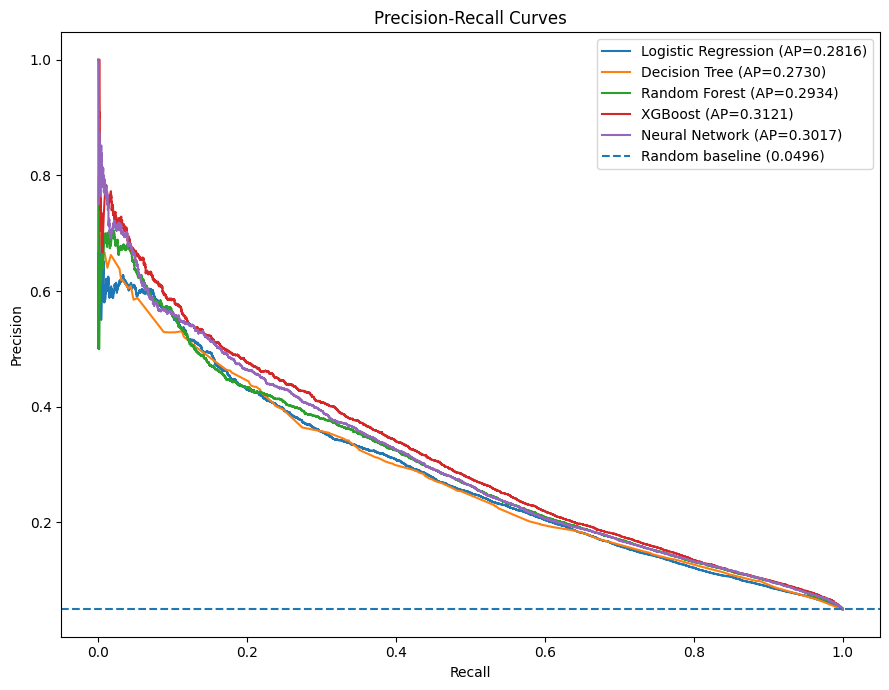

In [79]:
fig, ax = plt.subplots(
    figsize=(9, 7)
)

for name, probabilities in (
    test_probabilities.items()
):

    precision, recall, _ = (
        precision_recall_curve(
            y_test,
            probabilities
        )
    )

    ap = average_precision_score(
        y_test,
        probabilities
    )

    ax.plot(
        recall,
        precision,
        label=f"{name} (AP={ap:.4f})"
    )

baseline = y_test.mean()

ax.axhline(
    baseline,
    linestyle="--",
    label=f"Random baseline ({baseline:.4f})"
)

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title(
    "Precision-Recall Curves"
)

ax.legend()
plt.tight_layout()
plt.show()

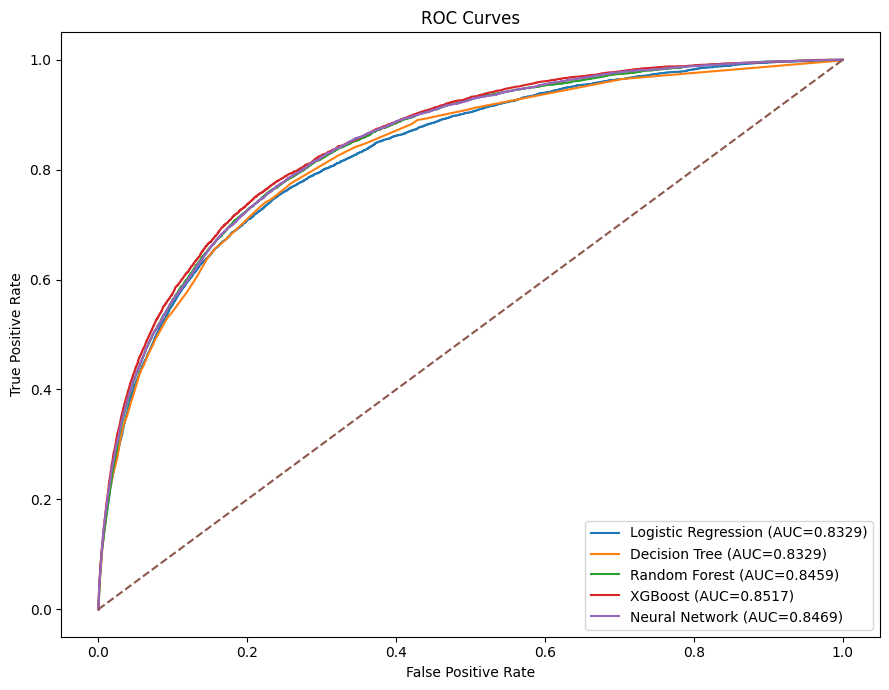

In [80]:
fig, ax = plt.subplots(
    figsize=(9, 7)
)

for name, probabilities in (
    test_probabilities.items()
):

    fpr, tpr, _ = roc_curve(
        y_test,
        probabilities
    )

    auc_value = roc_auc_score(
        y_test,
        probabilities
    )

    ax.plot(
        fpr,
        tpr,
        label=(
            f"{name} "
            f"(AUC={auc_value:.4f})"
        )
    )

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

ax.set_xlabel(
    "False Positive Rate"
)
ax.set_ylabel(
    "True Positive Rate"
)
ax.set_title(
    "ROC Curves"
)

ax.legend()
plt.tight_layout()
plt.show()

## 21.2 Confusion Matrix

The confusion matrix for the selected model shows the number of:

- true negatives;
- false positives;
- false negatives;
- true positives.

This makes the practical consequences of the model easier to interpret than a single summary metric.

In [81]:
best_model = final_models[
    best_model_name
]

best_test_prob = test_probabilities[
    best_model_name
]

best_threshold = float(
    validation_results_df.loc[
        validation_results_df[
            "Model"
        ] == best_model_name,
        "Optimised_Threshold"
    ].iloc[0]
)

best_test_pred = (
    best_test_prob >= best_threshold
).astype(int)

cm = confusion_matrix(
    y_test,
    best_test_pred
)

cm

array([[112453,   4927],
       [  3630,   2501]])

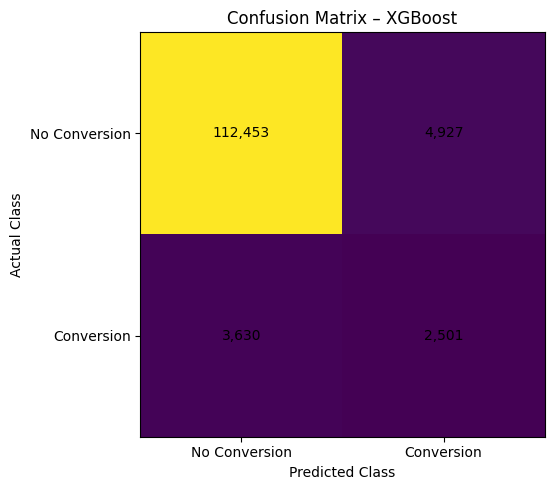

In [82]:
fig, ax = plt.subplots(
    figsize=(6, 5)
)

image = ax.imshow(cm)

ax.set_title(
    f"Confusion Matrix – {best_model_name}"
)

ax.set_xlabel(
    "Predicted Class"
)

ax.set_ylabel(
    "Actual Class"
)

ax.set_xticks(
    [0, 1],
    labels=[
        "No Conversion",
        "Conversion"
    ]
)

ax.set_yticks(
    [0, 1],
    labels=[
        "No Conversion",
        "Conversion"
    ]
)

for i in range(2):
    for j in range(2):
        ax.text(
            j,
            i,
            f"{cm[i, j]:,}",
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

# 22. Feature Importance

Feature importance is examined to understand which advertising signals contributed most strongly to the selected model's predictions.

Interpretation must be cautious because the contextual categorical variables are anonymised. Therefore, the analysis can identify which variables are predictive but cannot always assign a meaningful real-world description to each category.

Feature importance represents predictive association rather than proof that a variable causes conversion.

In [83]:
if hasattr(
    best_model,
    "feature_importances_"
):

    importance_values = (
        best_model.feature_importances_
    )

elif hasattr(
    best_model,
    "coef_"
):

    importance_values = np.abs(
        best_model.coef_[0]
    )

else:
    importance_values = None

In [84]:
if importance_values is not None:

    importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importance_values
    })

    importance_df = (
        importance_df
        .sort_values(
            "Importance",
            ascending=False
        )
        .head(20)
    )

    importance_df

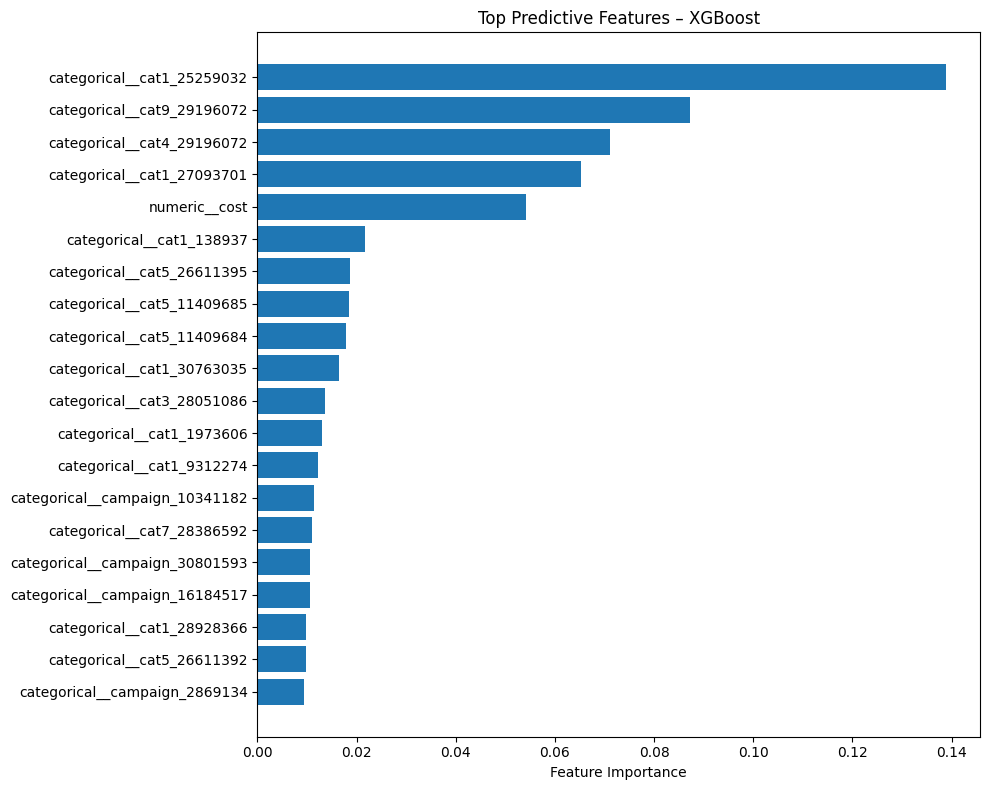

In [85]:
if importance_values is not None:

    plot_df = importance_df.sort_values(
        "Importance"
    )

    fig, ax = plt.subplots(
        figsize=(10, 8)
    )

    ax.barh(
        plot_df["Feature"],
        plot_df["Importance"]
    )

    ax.set_title(
        f"Top Predictive Features – {best_model_name}"
    )

    ax.set_xlabel(
        "Feature Importance"
    )

    plt.tight_layout()
    plt.show()

# 23. Advertising Lift Analysis

Traditional machine-learning metrics describe statistical performance, but advertisers are also interested in whether a model can concentrate likely converters into a smaller group of impressions.

A lift analysis is therefore performed.

Test impressions are ranked from highest to lowest predicted conversion probability and divided into ten groups of equal size.

The conversion rate within each group is compared with the overall test-set conversion rate.

A lift greater than 1 indicates that the selected group contains converters at a higher rate than random impression selection.

In [86]:
lift_df = pd.DataFrame({
    "Actual": y_test.to_numpy(),
    "Probability": best_test_prob
})

lift_df = (
    lift_df
    .sort_values(
        "Probability",
        ascending=False
    )
    .reset_index(drop=True)
)

lift_df["Decile"] = pd.qcut(
    np.arange(len(lift_df)),
    q=10,
    labels=range(1, 11)
)

baseline_conversion_rate = (
    lift_df["Actual"].mean()
)

lift_summary = (
    lift_df.groupby(
        "Decile",
        observed=False
    )
    .agg(
        Impressions=("Actual", "size"),
        Conversions=("Actual", "sum"),
        Conversion_Rate=("Actual", "mean"),
        Average_Score=(
            "Probability",
            "mean"
        )
    )
    .reset_index()
)

lift_summary["Lift"] = (
    lift_summary["Conversion_Rate"] /
    baseline_conversion_rate
)

lift_summary

,Decile,Impressions,Conversions,Conversion_Rate,Average_Score,Lift
0,1,12352,3229,0.261415,0.249788,5.266294
1,2,12351,1086,0.087928,0.083611,1.771340
2,3,12351,616,0.049875,0.048709,1.004738
3,4,12351,433,0.035058,0.032998,0.706253
4,5,12351,302,0.024451,0.023903,0.492583
5,6,12351,198,0.016031,0.017681,0.322952
6,7,12351,126,0.010202,0.013016,0.205515
7,8,12351,72,0.005829,0.009173,0.117437
8,9,12351,44,0.003562,0.005934,0.071767
9,10,12351,25,0.002024,0.003401,0.040777


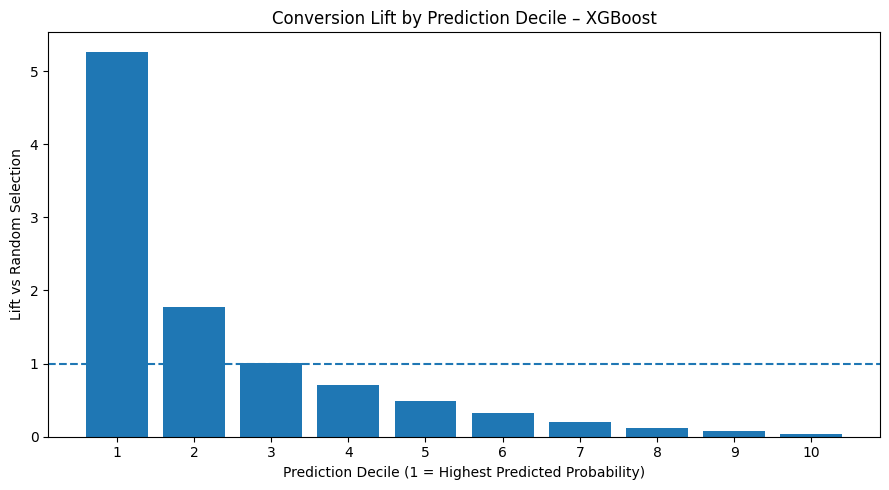

In [87]:
fig, ax = plt.subplots(
    figsize=(9, 5)
)

ax.bar(
    lift_summary[
        "Decile"
    ].astype(str),
    lift_summary["Lift"]
)

ax.axhline(
    1,
    linestyle="--"
)

ax.set_title(
    f"Conversion Lift by Prediction Decile – {best_model_name}"
)

ax.set_xlabel(
    "Prediction Decile (1 = Highest Predicted Probability)"
)

ax.set_ylabel(
    "Lift vs Random Selection"
)

plt.tight_layout()
plt.show()

# 24. Probability Calibration

Conversion prediction is potentially useful for bidding and budget allocation only if predicted probabilities have meaningful relationships with observed conversion rates.

A calibration analysis therefore compares predicted probability with actual conversion frequency.

A perfectly calibrated model would produce observed conversion rates close to its predicted probabilities.

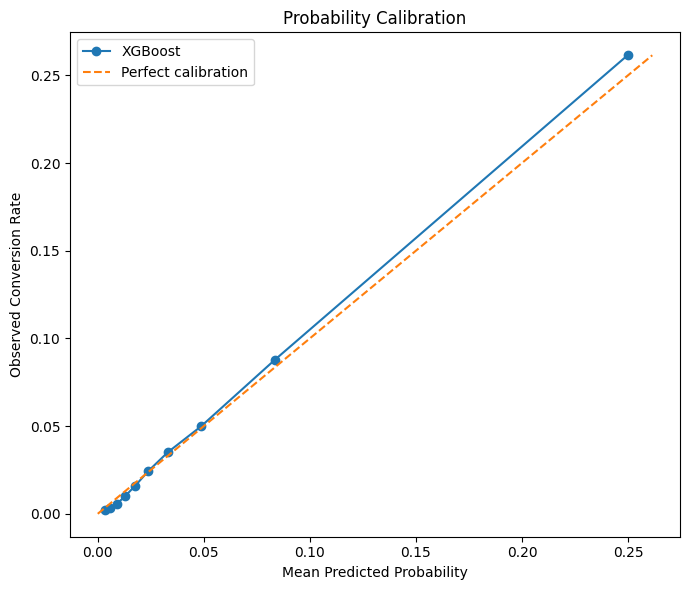

In [88]:
from sklearn.calibration import calibration_curve

fraction_positive, mean_predicted = (
    calibration_curve(
        y_test,
        best_test_prob,
        n_bins=10,
        strategy="quantile"
    )
)

fig, ax = plt.subplots(
    figsize=(7, 6)
)

ax.plot(
    mean_predicted,
    fraction_positive,
    marker="o",
    label=best_model_name
)

max_value = max(
    mean_predicted.max(),
    fraction_positive.max()
)

ax.plot(
    [0, max_value],
    [0, max_value],
    linestyle="--",
    label="Perfect calibration"
)

ax.set_xlabel(
    "Mean Predicted Probability"
)

ax.set_ylabel(
    "Observed Conversion Rate"
)

ax.set_title(
    "Probability Calibration"
)

ax.legend()

plt.tight_layout()
plt.show()

# 25. Click-Informed Ablation Experiment

The primary model intentionally excludes `click` because a click occurs after an impression has been delivered.

However, click behaviour is likely to contain substantial information about subsequent conversion probability.

A separate diagnostic experiment is therefore performed using click as an additional input variable.

This experiment does **not** represent the main impression-time prediction model.

Its purpose is to quantify how predictive performance changes once post-impression engagement information becomes available.

A large performance increase would also demonstrate why careful feature-timing and leakage analysis is important when evaluating advertising prediction models.

In [89]:
click_numeric_features = (
    numeric_features +
    ["click"]
)

click_features = (
    categorical_features +
    click_numeric_features
)

X_click_train = train_df[
    click_features
].copy()

X_click_val = val_df[
    click_features
].copy()

X_click_test = test_df[
    click_features
].copy()

In [90]:
click_preprocessor = ColumnTransformer([
    (
        "numeric",
        numeric_pipeline,
        click_numeric_features
    ),
    (
        "categorical",
        categorical_pipeline,
        categorical_features
    )
])

X_click_train_processed = (
    click_preprocessor.fit_transform(
        X_click_train
    )
)

X_click_val_processed = (
    click_preprocessor.transform(
        X_click_val
    )
)

X_click_test_processed = (
    click_preprocessor.transform(
        X_click_test
    )
)

In [91]:
click_xgb = XGBClassifier(
    n_estimators=int(
        best_xgb["n_estimators"]
    ),
    max_depth=int(
        best_xgb["max_depth"]
    ),
    learning_rate=float(
        best_xgb["learning_rate"]
    ),
    scale_pos_weight=float(
        best_xgb["scale_pos_weight"]
    ),
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

click_xgb.fit(
    X_click_train_processed,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=-1,
              num_parallel_tree=None, ...)

In [92]:
click_val_prob = (
    click_xgb.predict_proba(
        X_click_val_processed
    )[:, 1]
)

click_threshold, _ = (
    find_best_f1_threshold(
        y_val,
        click_val_prob
    )
)

click_test_prob = (
    click_xgb.predict_proba(
        X_click_test_processed
    )[:, 1]
)

click_results = (
    evaluate_probabilities(
        y_test,
        click_test_prob,
        threshold=click_threshold
    )
)

In [93]:
strict_xgb_results = (
    test_results_df.loc[
        test_results_df[
            "Model"
        ] == "XGBoost"
    ].iloc[0]
)

ablation_comparison = pd.DataFrame([
    {
        "Model": "XGBoost - Impression-Time Features",
        "PR_AUC": strict_xgb_results[
            "PR_AUC"
        ],
        "ROC_AUC": strict_xgb_results[
            "ROC_AUC"
        ],
        "F1": strict_xgb_results[
            "F1"
        ],
        "Log_Loss": strict_xgb_results[
            "Log_Loss"
        ]
    },
    {
        "Model": "XGBoost + Post-Impression Click",
        "PR_AUC": click_results[
            "PR_AUC"
        ],
        "ROC_AUC": click_results[
            "ROC_AUC"
        ],
        "F1": click_results[
            "F1"
        ],
        "Log_Loss": click_results[
            "Log_Loss"
        ]
    }
])

ablation_comparison

,Model,PR_AUC,ROC_AUC,F1,Log_Loss
0,XGBoost - Impression-Time Features,0.312056,0.851707,0.368906,0.150595
1,XGBoost + Post-Impression Click,0.530007,0.945581,0.522919,0.107777


# 26. Summary of Findings

The modelling experiment was designed to answer the research question:

**To what extent can machine-learning models predict whether a digital display advertising impression will be followed by a conversion, and which modelling approach provides the best performance for this highly imbalanced classification problem?**

The final interpretation will consider:

1. which model achieved the strongest PR-AUC;
2. whether the stronger model also performed well on ROC-AUC, Precision, Recall and F1-score;
3. whether model probabilities were well calibrated;
4. whether optimisation improved performance over the initial models;
5. how well the model concentrated converters into high-scoring impression groups;
6. which advertising variables were most predictive;
7. how performance changed when post-impression click information was included;
8. whether the model appears practically useful for advertising optimisation.

The results will be interpreted in relation to the academic literature and the limitations of observational advertising data.

# 27. Ethical and Privacy Considerations

The dataset was publicly released by Criteo for research and contains anonymised advertising information rather than directly identifiable user information.

Nevertheless, predictive advertising raises several ethical considerations.

### Privacy

Although user identifiers and contextual variables have been anonymised, advertising behavioural data can still contain information about user activity. The project therefore avoids attempting to identify users or infer the hidden meaning of anonymised characteristics.

### Data minimisation

The raw user identifier is excluded from the primary prediction model. The objective is to learn generalisable conversion patterns rather than memorise individual users.

### Predictive targeting

A model that predicts conversion probability could be used to allocate advertising opportunities preferentially towards particular groups. Poorly designed targeting systems could reinforce existing behavioural or demographic biases.

### Transparency

Machine-learning predictions are probabilistic estimates. A high predicted conversion probability does not guarantee that a particular individual will convert.

### Causality

The project predicts observed conversion outcomes. It does not demonstrate that exposure to an advertisement caused a conversion.

This distinction is important because observational advertising data may contain existing differences between users who are more or less likely to purchase regardless of advertising exposure.

### Responsible use

The practical purpose of predictive modelling should be to improve advertising relevance and efficiency without creating intrusive or discriminatory targeting practices.

The project uses the dataset solely for academic research and does not attempt to de-anonymise users.

# 28. Limitations

Several limitations should be considered when interpreting the results.

First, the dataset contains anonymised contextual variables. This protects commercially sensitive and personal information but limits the ability to provide detailed real-world explanations for individual categorical features.

Second, the project uses a representative sample of the complete dataset because of computational constraints. Although the sampling procedure is designed to preserve the original class distribution and temporal coverage, training on the complete dataset may produce different results.

Third, conversion is an extremely rare outcome. Small changes in the number of correctly identified conversions can therefore have substantial effects on Precision and Recall.

Fourth, advertising behaviour can change over time. A model trained using one historical period may not retain the same performance when campaign strategy, audiences or market conditions change.

Fifth, this is an observational dataset. Predictive association should not be interpreted as causal advertising effectiveness.

Finally, the analysis uses anonymised transformed advertising costs rather than actual commercial prices, limiting direct financial interpretation of the models.

# 29. Future Work

Future research could extend this project in several ways.

The analysis could be repeated using the complete Criteo dataset with greater computing resources.

More advanced approaches to categorical variables could be explored, including categorical boosting and neural embeddings.

Probability calibration methods could be applied to improve the quality of estimated conversion probabilities.

Sequential models could also represent the complete user advertising journey rather than treating each impression as an independent observation.

Future research could incorporate causal or uplift modelling to distinguish users whose behaviour is genuinely influenced by advertising from users who would have converted without exposure.

Finally, model performance could be evaluated using explicit advertising utility measures combining conversion probability, advertising cost and expected customer value.

In [94]:
# Save major results

test_results_df.to_csv(
    "/content/final_model_results.csv",
    index=False
)

validation_results_df.to_csv(
    "/content/validation_model_results.csv",
    index=False
)

lift_summary.to_csv(
    "/content/lift_analysis.csv",
    index=False
)

ablation_comparison.to_csv(
    "/content/click_ablation_results.csv",
    index=False
)

print("Results saved successfully.")

Results saved successfully.


# 30. Reproducibility

A fixed random seed was used for sampling, model development and optimisation wherever supported.

The project records the versions of the primary Python libraries used.

The complete notebook will be stored in the project's GitHub repository together with a README explaining the dataset, modelling process and instructions for reproducing the analysis.

Development versions of the notebook and code will be committed throughout the project in order to provide evidence of project progression.